# Credit Cycle Stressboard 

**Purpose.** Build a reproducible pipeline that:
1) pulls macro & market series (FRED + LSEG/Eikon),  
2) stores **raw** and **feature-engineered** data in **Supabase**,  
3) later derives a **monthly stress composite** that drives a **risk-on / risk-off** sleeve strategy.

**What this notebook covers (setup phase)**
- ✅ Load secrets from `.env` (with `api_key.txt` fallback for Eikon).
- ✅ Initialize clients: **Supabase**, **Eikon**, **FRED** (if key provided).
- ✅ Define project constants: table names, series catalog, ETF universe, scenarios, default run window.

**Secrets expected**
- `SUPABASE_URL`, `SUPABASE_SERVICE_ROLE` 
- `EIKON_APP_KEY` 
- `FRED_API_KEY` 

**Supabase schema (already provisioned)**
- `series_meta(series_id, name, source, frequency, units, notes, tag, created_at)`
- `macro_series(series_id, date, value, load_ts)`
- `macro_features(series_id, date, value, d1, d3, yoy, z_5y, load_ts)`
- `market_prices(symbol, date, open, high, low, close, volume, source, load_ts)`
- `backtests(run_id, params_json, start_date, end_date, summary_json, created_at)`
- `backtest_daily(run_id, date, nav, sleeve, alloc_json)`
- `scenario_pnl(scenario_code, name, start_date, end_date, strategy_return, strategy_mdd, spy_return, spy_mdd, b6040_return, b6040_mdd, created_at)`
- `tuning_results(grid_id, threshold, ann_return, ann_vol, sharpe, max_drawdown, created_at)`




In [1]:
# import libraries
import os, sys, math, json, warnings
from pathlib import Path
from datetime import datetime, date, timedelta
from typing import Optional, Dict, List

# Data & plotting
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# APIs / clients
import eikon as ek                 # LSEG / Eikon
from fredapi import Fred           # FRED client

# Supabase client (PostgREST)
from supabase import create_client, Client

# Utilities
from dotenv import load_dotenv

# Notebook display
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 50)
warnings.filterwarnings("ignore", category=FutureWarning)


In [18]:
# Load all secrets from .env
load_dotenv(override=True)

# Required
SUPABASE_URL          = os.environ["SUPABASE_URL"].strip()
SUPABASE_SERVICE_ROLE = os.environ["SUPABASE_SERVICE_ROLE"].strip()
EIKON_APP_KEY         = os.environ["EIKON_APP_KEY"].strip()

# Optional
PUBLIC_SUPABASE_ANON_KEY = os.getenv("PUBLIC_SUPABASE_ANON_KEY", "").strip()
FRED_API_KEY             = os.getenv("FRED_API_KEY", "").strip()

# Initialize clients
ek.set_app_key(EIKON_APP_KEY)
sb: Client = create_client(SUPABASE_URL, SUPABASE_SERVICE_ROLE)
sb_public: Optional[Client] = create_client(SUPABASE_URL, PUBLIC_SUPABASE_ANON_KEY) if PUBLIC_SUPABASE_ANON_KEY else None
fred = Fred(FRED_API_KEY) if FRED_API_KEY else None

# Project metadata
PROJECT_TAG = "credit_stressboard_v1"
TABLES = {
    "series_meta":     "series_meta",
    "macro_series":    "macro_series",
    "macro_features":  "macro_features",
    "market_prices":   "market_prices",
    "backtests":       "backtests",
    "backtest_daily":  "backtest_daily",
    "scenario_pnl":    "scenario_pnl",
    "tuning_results":  "tuning_results",
}



In [3]:
# FRED series catalog (high-confidence IDs) 
FRED_SERIES = [
    # Credit spreads & volatility
    {"series_id": "BAMLH0A0HYM2",   "name": "ICE BofA US High Yield OAS",           "freq": "D", "units": "bp",   "notes": "level, Δ1m, Δ3m, z"},
    {"series_id": "BAMLC0A0CM",     "name": "ICE BofA US IG Corporate OAS",         "freq": "D", "units": "bp",   "notes": "level, Δ1m, Δ3m, z"},
    {"series_id": "VIXCLS",         "name": "CBOE VIX Index (close)",               "freq": "D", "units": "index","notes": "level, Δ1m, Δ3m, z"},

    # Labor & consumer stress
    {"series_id": "UNRATE",         "name": "Unemployment Rate",                    "freq": "M", "units": "%",    "notes": "3m change, YoY, z"},
    {"series_id": "DRCCLACBS",      "name": "Credit Card Delinquency Rate (Banks)", "freq": "Q", "units": "%",    "notes": "QoQ Δ, z"},
    {"series_id": "DRSFRMACBS",     "name": "Mortgage Delinquency Rate (Banks)",    "freq": "Q", "units": "%",    "notes": "QoQ Δ, z"},

    # Spending & activity
    {"series_id": "PCEC96",         "name": "Real PCE",                             "freq": "M", "units": "USD",  "notes": "MoM ann., YoY"},
    {"series_id": "RSXFS",          "name": "Retail & Food Sales ex Auto (Adv.)",   "freq": "M", "units": "USD",  "notes": "MoM ann., YoY"},

    # Funding & rates
    {"series_id": "SOFR",           "name": "Secured Overnight Financing Rate",     "freq": "D", "units": "%",    "notes": "level"},
    {"series_id": "SOFR30DAYAVG",   "name": "30-Day Average SOFR",                  "freq": "D", "units": "%",    "notes": "level"},
    {"series_id": "RRPONTSYD",      "name": "Overnight RRP (usage, end of day)",    "freq": "D", "units": "USD",  "notes": "z-score"},
    {"series_id": "MORTGAGE30US",   "name": "30-Year Fixed Mortgage Rate",          "freq": "W", "units": "%",    "notes": "level"},
    {"series_id": "DGS10",          "name": "10-Year Treasury Yield",               "freq": "D", "units": "%",    "notes": "risk-free proxy"},

    # Commodities (shock channels)
    {"series_id": "DCOILWTICO",     "name": "WTI Crude Oil (daily spot)",           "freq": "D", "units": "USD",  "notes": "3m %Δ, z"},
    {"series_id": "DHHNGSP",        "name": "Henry Hub Natural Gas (spot)",         "freq": "D", "units": "USD",  "notes": "3m %Δ, z"},
]

#  Market ETFs (symbols; RICs resolved in a later step) 
# Keep 'symbol' for universal reference; RICs can vary by venue—resolve next.
ETFS = [
    {"symbol": "SPY", "role": "risk_on",  "note": "US equity proxy"},
    {"symbol": "HYG", "role": "risk_on",  "note": "US high yield credit"},
    {"symbol": "LQD", "role": "risk_on",  "note": "US IG credit"},

    {"symbol": "SH",  "role": "risk_off", "note": "-1x S&P 500"},
    {"symbol": "PSQ", "role": "risk_off", "note": "-1x Nasdaq-100"},
    {"symbol": "SJB", "role": "risk_off", "note": "-1x high yield"},

    {"symbol": "IEF", "role": "risk_off", "note": "7–10y UST"},
    {"symbol": "TLT", "role": "risk_off", "note": "20y+ UST"},
]

# CDS universe (placeholders; resolve to specific LSEG instruments later) 
CDS_UNIVERSE = [
    {"issuer": "JPMorgan Chase", "ticker": "JPM", "tenor_yr": 5, "currency": "USD", "ric": None},
    {"issuer": "Bank of America","ticker": "BAC", "tenor_yr": 5, "currency": "USD", "ric": None},
    {"issuer": "Citigroup",      "ticker": "C",   "tenor_yr": 5, "currency": "USD", "ric": None},
    {"issuer": "Goldman Sachs",  "ticker": "GS",  "tenor_yr": 5, "currency": "USD", "ric": None},
    {"issuer": "Morgan Stanley", "ticker": "MS",  "tenor_yr": 5, "currency": "USD", "ric": None},
]

# Ratings scope (broad; we will filter by sector/universe later) 
RATINGS_SCOPE = {
    "agencies": ["Moody's", "S&P"],
    "universe_note": "US large caps; store monthly counts of upgrades/downgrades by sector."
}

# Scenario catalog (for stress replays) 
SCENARIOS = [
    {"code": "GFC_2008",   "name": "Global Financial Crisis", "start": "2008-09-01", "end": "2009-06-30"},
    {"code": "COVID_2020", "name": "COVID Shock",             "start": "2020-02-15", "end": "2020-04-30"},
    {"code": "HIKES_2022", "name": "Hiking Cycle",            "start": "2022-01-01", "end": "2022-10-31"},
    {"code": "OIL_2014",   "name": "Oil Crash",               "start": "2014-06-01", "end": "2016-02-29"},
]

# Default run window 
RUN = {
    "start_date": "2003-01-01",
    "end_date":   date.today().isoformat()
}

# Build a tidy meta dataframe for FRED series
series_meta_df = pd.DataFrame([
    {
        "series_id": s["series_id"],
        "name":      s["name"],
        "source":    "FRED",
        "frequency": s["freq"],
        "units":     s["units"],
        "notes":     s["notes"],
        "tag":       "credit_stressboard_v1"
    }
    for s in FRED_SERIES
])

print("Catalog ready.")
print(f"• FRED series: {len(FRED_SERIES)}")
print(f"• ETFs:        {len(ETFS)}")
print(f"• CDS names:   {len(CDS_UNIVERSE)}")
print(f"• Scenarios:   {len(SCENARIOS)}")
print(f"• Run window:  {RUN['start_date']} → {RUN['end_date']}")
series_meta_df.head(6)


Catalog ready.
• FRED series: 15
• ETFs:        8
• CDS names:   5
• Scenarios:   4
• Run window:  2003-01-01 → 2025-11-05


,series_id,name,source,frequency,units,notes,tag
0,BAMLH0A0HYM2,ICE BofA US High Yield OAS,FRED,D,bp,"level, Δ1m, Δ3m, z",credit_stressboard_v1
1,BAMLC0A0CM,ICE BofA US IG Corporate OAS,FRED,D,bp,"level, Δ1m, Δ3m, z",credit_stressboard_v1
2,VIXCLS,CBOE VIX Index (close),FRED,D,index,"level, Δ1m, Δ3m, z",credit_stressboard_v1
3,UNRATE,Unemployment Rate,FRED,M,%,"3m change, YoY, z",credit_stressboard_v1
4,DRCCLACBS,Credit Card Delinquency Rate (Banks),FRED,Q,%,"QoQ Δ, z",credit_stressboard_v1
5,DRSFRMACBS,Mortgage Delinquency Rate (Banks),FRED,Q,%,"QoQ Δ, z",credit_stressboard_v1


The setup succeeded: environment keys loaded, and the data catalog is defined with **15** FRED series, **8** ETFs, and **4** stress scenarios spanning **2003-01-01 → 2025-11-04**. This gives broad macro and market coverage to compute monthly z-scores and a composite stress index. 

In [5]:
# Supabase upsert helper 
def upsert_df(table: str, df: pd.DataFrame, on_conflict: str, chunk: int = 1000):
    if df is None or df.empty:
        return
    records = df.to_dict(orient="records")
    for i in range(0, len(records), chunk):
        payload = records[i:i+chunk]
        sb.table(table).upsert(payload, on_conflict=on_conflict).execute()

# Prepare and load series_meta (from the catalog cell you already ran)
assert "series_meta_df" in globals() and not series_meta_df.empty
upsert_df("series_meta", series_meta_df, on_conflict="series_id")

print(f"series_meta rows upserted: {len(series_meta_df)}")
series_meta_df.head(8)

series_meta rows upserted: 15


,series_id,name,source,frequency,units,notes,tag
0,BAMLH0A0HYM2,ICE BofA US High Yield OAS,FRED,D,bp,"level, Δ1m, Δ3m, z",credit_stressboard_v1
1,BAMLC0A0CM,ICE BofA US IG Corporate OAS,FRED,D,bp,"level, Δ1m, Δ3m, z",credit_stressboard_v1
2,VIXCLS,CBOE VIX Index (close),FRED,D,index,"level, Δ1m, Δ3m, z",credit_stressboard_v1
3,UNRATE,Unemployment Rate,FRED,M,%,"3m change, YoY, z",credit_stressboard_v1
4,DRCCLACBS,Credit Card Delinquency Rate (Banks),FRED,Q,%,"QoQ Δ, z",credit_stressboard_v1
5,DRSFRMACBS,Mortgage Delinquency Rate (Banks),FRED,Q,%,"QoQ Δ, z",credit_stressboard_v1
6,PCEC96,Real PCE,FRED,M,USD,"MoM ann., YoY",credit_stressboard_v1
7,RSXFS,Retail & Food Sales ex Auto (Adv.),FRED,M,USD,"MoM ann., YoY",credit_stressboard_v1


The `series_meta` catalog is now registered in Supabase: **15** FRED series upserted idempotently (duplicates resolved via `on_conflict='series_id'`). This gives downstream queries a stable reference for names, frequencies, units, and notes. **Next:** fetch raw FRED series and load into `macro_series` to begin feature engineering.


In [7]:
#  FRED fetch → tidy → load 
def fetch_fred_series(series_id: str, start_date: str, end_date: str) -> pd.DataFrame:
    # Use fredapi client if configured; otherwise CSV endpoint
    if fred is not None:
        s = fred.get_series(series_id, observation_start=start_date, observation_end=end_date)
        df = s.to_frame("value").reset_index().rename(columns={"index": "date"})
    else:
        url = (
            "https://fred.stlouisfed.org/graph/fredgraph.csv"
            f"?id={series_id}&cosd={start_date}&coed={end_date}"
        )
        df = pd.read_csv(url)
        df = df.rename(columns={"DATE": "date", series_id: "value"})
    # Normalize types (keep as pandas types for now)
    df["series_id"] = series_id
    df["date"] = pd.to_datetime(df["date"])
    df["value"] = pd.to_numeric(df["value"], errors="coerce")
    df = (
        df.dropna(subset=["value"])
          .drop_duplicates(subset=["series_id", "date"])
          .sort_values("date")
          .loc[:, ["series_id", "date", "value"]]
    )
    return df

# Build and load all FRED series from the catalog
assert "FRED_SERIES" in globals() and isinstance(FRED_SERIES, list)
frames: list[pd.DataFrame] = []
for s in FRED_SERIES:
    sid = s["series_id"]
    df = fetch_fred_series(sid, RUN["start_date"], RUN["end_date"])
    frames.append(df)

macro_df = pd.concat(frames, ignore_index=True)

# Make JSON-serializable for Supabase upsert 
# date -> 'YYYY-MM-DD', load_ts -> ISO8601 Zulu, value -> float
macro_df["date"] = pd.to_datetime(macro_df["date"]).dt.strftime("%Y-%m-%d")
macro_df["value"] = macro_df["value"].astype(float)
macro_df["load_ts"] = pd.Timestamp.utcnow().strftime("%Y-%m-%dT%H:%M:%SZ")
# Replace NaN with None for JSON
macro_df = macro_df.replace({np.nan: None})

# Upsert to Supabase (PK: series_id, date)
upsert_df("macro_series", macro_df, on_conflict="series_id,date")

print(
    "macro_series upsert:",
    f"{macro_df['series_id'].nunique()} series,",
    f"{len(macro_df):,} rows"
)
macro_df.head(10)


macro_series upsert: 15 series, 43,910 rows


,series_id,date,value,load_ts
0,BAMLH0A0HYM2,2003-01-02,8.65,2025-11-05T17:48:03Z
1,BAMLH0A0HYM2,2003-01-03,8.57,2025-11-05T17:48:03Z
2,BAMLH0A0HYM2,2003-01-06,8.41,2025-11-05T17:48:03Z
3,BAMLH0A0HYM2,2003-01-07,8.26,2025-11-05T17:48:03Z
4,BAMLH0A0HYM2,2003-01-08,8.18,2025-11-05T17:48:03Z
5,BAMLH0A0HYM2,2003-01-09,7.95,2025-11-05T17:48:03Z
6,BAMLH0A0HYM2,2003-01-10,7.92,2025-11-05T17:48:03Z
7,BAMLH0A0HYM2,2003-01-13,7.92,2025-11-05T17:48:03Z
8,BAMLH0A0HYM2,2003-01-14,7.96,2025-11-05T17:48:03Z
9,BAMLH0A0HYM2,2003-01-15,7.96,2025-11-05T17:48:03Z


Successfully loaded 15 FRED series into macro_series with 43,905 total rows, dates normalized to YYYY-MM-DD and UTC load_ts (e.g., 2025-11-05T01:21:36Z, which is evening Nov 4 ET). Duplicates and NaNs were removed, so the table is clean and upsert-safe. You’re ready to compute features (d1, d3, yoy, z_5y) and build the monthly stress composite.

In [9]:
# Build transforms from the raw macro_df you already created
assert "series_meta_df" in globals() and not series_meta_df.empty
assert "macro_df" in globals() and not macro_df.empty

m_raw = macro_df.copy()
m_raw["date"] = pd.to_datetime(m_raw["date"])  # from 'YYYY-MM-DD' string
meta = series_meta_df[["series_id","frequency"]].drop_duplicates()

# Window map per frequency
win = {
    "D": {"d1": 21,  "d3": 63,  "yoy": 252, "z": 1260},
    "W": {"d1": 13,  "d3": 26,  "yoy": 52,  "z": 260},
    "M": {"d1": 1,   "d3": 3,   "yoy": 12,  "z": 60},
    "Q": {"d1": 1,   "d3": 4,   "yoy": 4,   "z": 20},
}

def compute_group_feats(df: pd.DataFrame, freq: str) -> pd.DataFrame:
    df = df.sort_values("date").copy()
    v = df["value"].astype(float)

    w = win.get(freq, win["M"])
    n1, n3, ny, nz = w["d1"], w["d3"], w["yoy"], w["z"]

    d1  = v - v.shift(n1)
    d3  = v - v.shift(n3)
    yoy = v / v.shift(ny) - 1.0

    mean = v.rolling(nz, min_periods=max(5, n1)).mean()
    std  = v.rolling(nz, min_periods=max(5, n1)).std(ddof=0)
    z5y  = (v - mean) / std

    out = df[["series_id","date","value"]].copy()
    out["d1"]   = d1
    out["d3"]   = d3
    out["yoy"]  = yoy
    out["z_5y"] = z5y
    return out

m = m_raw.merge(meta, on="series_id", how="left")

feats = []
for sid, g in m.groupby("series_id", sort=False):
    freq = (g["frequency"].iloc[0] or "M").strip().upper()
    feats.append(compute_group_feats(g, freq))

macro_features_df = pd.concat(feats, ignore_index=True)

# JSON-safe & sanitized
macro_features_df["date"]    = macro_features_df["date"].dt.strftime("%Y-%m-%d")
for c in ["value","d1","d3","yoy","z_5y"]:
    macro_features_df[c] = pd.to_numeric(macro_features_df[c], errors="coerce")
macro_features_df[["value","d1","d3","yoy","z_5y"]] = macro_features_df[["value","d1","d3","yoy","z_5y"]].replace([np.inf,-np.inf], np.nan)
macro_features_df["load_ts"] = pd.Timestamp.utcnow().strftime("%Y-%m-%dT%H:%M:%SZ")
macro_features_df = macro_features_df.replace({np.nan: None})

upsert_df("macro_features", macro_features_df, on_conflict="series_id,date")

print(
    "macro_features upsert:",
    f"{macro_features_df['series_id'].nunique()} series,",
    f"{len(macro_features_df):,} rows"
)
macro_features_df.head(8)


macro_features upsert: 15 series, 43,910 rows


,series_id,date,value,d1,d3,yoy,z_5y,load_ts
0,BAMLH0A0HYM2,2003-01-02,8.65,None,None,None,None,2025-11-05T17:48:15Z
1,BAMLH0A0HYM2,2003-01-03,8.57,None,None,None,None,2025-11-05T17:48:15Z
2,BAMLH0A0HYM2,2003-01-06,8.41,None,None,None,None,2025-11-05T17:48:15Z
3,BAMLH0A0HYM2,2003-01-07,8.26,None,None,None,None,2025-11-05T17:48:15Z
4,BAMLH0A0HYM2,2003-01-08,8.18,None,None,None,None,2025-11-05T17:48:15Z
5,BAMLH0A0HYM2,2003-01-09,7.95,None,None,None,None,2025-11-05T17:48:15Z
6,BAMLH0A0HYM2,2003-01-10,7.92,None,None,None,None,2025-11-05T17:48:15Z
7,BAMLH0A0HYM2,2003-01-13,7.92,None,None,None,None,2025-11-05T17:48:15Z


Feature engineering landed in macro_features for 15 series (43,905 rows). The early rows show None for d1/d3/yoy/z_5y as expected—each metric needs lookback (e.g., ~21/63/252/1260 periods for D-frequency; smaller for M/Q). 

In [11]:
# Ensure we have features in-memory
assert "macro_features_df" in globals() and not macro_features_df.empty

CORE = ["BAMLH0A0HYM2","BAMLC0A0CM","VIXCLS","UNRATE","DRCCLACBS","DRSFRMACBS"]

z = macro_features_df[macro_features_df["series_id"].isin(CORE)].copy()
z["date"] = pd.to_datetime(z["date"])

# Month-end alignment per series, then pivot z_5y
z_me = (
    z.set_index("date")
     .groupby("series_id", group_keys=False)
     .apply(lambda g: g.resample("M").last())
     .reset_index()
)

zmat = z_me.pivot_table(index="date", columns="series_id", values="z_5y")
stress = zmat.mean(axis=1, skipna=True)  # equal-weight of available z's

# Register the synthetic series in series_meta if needed
stress_meta = pd.DataFrame([{
    "series_id": "STRESS_SCORE",
    "name":      "Macro-Credit Composite Stress Score (z)",
    "source":    "DERIVED",
    "frequency": "M",
    "units":     "z",
    "notes":     "Equal-weight of z_5y: HY OAS, IG OAS, VIX, UNRATE, CC Delinq, Mortgage Delinq",
    "tag":       PROJECT_TAG,
}])

upsert_df("series_meta", stress_meta, on_conflict="series_id")

# Upsert the composite into macro_series
stress_df = pd.DataFrame({
    "series_id": ["STRESS_SCORE"] * len(stress.index),
    "date":      stress.index.strftime("%Y-%m-%d"),
    "value":     stress.values.astype(float),
    "load_ts":   pd.Timestamp.utcnow().strftime("%Y-%m-%dT%H:%M:%SZ"),
}).replace({np.nan: None})

upsert_df("macro_series", stress_df, on_conflict="series_id,date")

print("Composite STRESS_SCORE upsert:", len(stress_df), "rows")
stress_df.tail(6)


C:\Users\chris\AppData\Local\Temp\ipykernel_32048\2282027260.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.resample("M").last())


Composite STRESS_SCORE upsert: 275 rows


,series_id,date,value,load_ts
269,STRESS_SCORE,2025-06-30,-0.786036,2025-11-05T17:48:29Z
270,STRESS_SCORE,2025-07-31,-0.841027,2025-11-05T17:48:29Z
271,STRESS_SCORE,2025-08-31,-0.826889,2025-11-05T17:48:29Z
272,STRESS_SCORE,2025-09-30,-1.076041,2025-11-05T17:48:29Z
273,STRESS_SCORE,2025-10-31,-0.851739,2025-11-05T17:48:29Z
274,STRESS_SCORE,2025-11-30,-0.621800,2025-11-05T17:48:29Z


In [12]:
# Non-null counts per feature by series
feat_counts = (
    pd.DataFrame({
        "series_id": macro_features_df["series_id"],
        "d1":  pd.to_numeric(macro_features_df["d1"], errors="coerce"),
        "d3":  pd.to_numeric(macro_features_df["d3"], errors="coerce"),
        "yoy": pd.to_numeric(macro_features_df["yoy"], errors="coerce"),
        "z_5y":pd.to_numeric(macro_features_df["z_5y"], errors="coerce"),
    })
    .groupby("series_id")
    .agg(d1_nnz=("d1","count"), d3_nnz=("d3","count"), yoy_nnz=("yoy","count"), z5y_nnz=("z_5y","count"))
    .sort_values("z5y_nnz", ascending=False)
)
feat_counts.head(10)


,d1_nnz,d3_nnz,yoy_nnz,z5y_nnz
series_id,,,,
BAMLH0A0HYM2,5945,5903,5714,5946
BAMLC0A0CM,5944,5902,5713,5945
VIXCLS,5754,5712,5523,5755
DHHNGSP,5718,5676,5487,5719
DCOILWTICO,5704,5662,5473,5705
DGS10,5693,5651,5462,5694
RRPONTSYD,3091,3049,2787,3092
SOFR,1876,1834,1645,1877
SOFR30DAYAVG,1856,1814,1625,1857




* The series at the top (HY OAS, IG OAS, VIX, commodities, 10Y) have the **highest non-null `z_5y` counts** because they’re **daily** and long-history; after a short warm-up, they contribute most months to the composite.
* `UNRATE` (M) and especially the **delinquency rates (Q)** will show **much smaller `z_5y` counts**: a 5-year z on quarterly data needs ~20 points before it’s non-null, so early years are blank.
* `SOFR`/`RRP` start late (2018/2013), so their `z_5y` counts are **lower by construction**, not an error.

**Implications:** your composite will **initially overweight the daily series** (more non-nulls). If you want balance, either (a) require a **minimum component count** per month (e.g., ≥4 of 6), (b) **down-weight daily** vs. monthly/quarterly series, or (c) compute each series’ z on a **common monthly sample** before averaging.


In [14]:
#  Monthly composite (robust: no duplicate 'series_id', no daily overweight) 
CORE = ["BAMLH0A0HYM2","BAMLC0A0CM","VIXCLS","UNRATE","DRCCLACBS","DRSFRMACBS"]

core_vals = macro_df.loc[macro_df["series_id"].isin(CORE), ["series_id","date","value"]].copy()
core_vals["date"]  = pd.to_datetime(core_vals["date"])
core_vals["value"] = pd.to_numeric(core_vals["value"], errors="coerce")
core_vals["month"] = core_vals["date"].dt.to_period("M")

# Month-end LAST value per series (no resample/reset_index bug)
core_m = (core_vals.sort_values(["series_id","date"])
                  .groupby(["series_id","month"], as_index=False)
                  .agg(value=("value","last")))
core_m["date"] = core_m["month"].dt.to_timestamp("M")
core_m = core_m.drop(columns="month")

# 5y rolling z on monthly sample
win, minp = 60, 36
g = core_m.groupby("series_id")["value"]
m = g.transform(lambda x: x.rolling(win, min_periods=minp).mean())
s = g.transform(lambda x: x.rolling(win, min_periods=minp).std(ddof=0))
core_m["z_m"] = (core_m["value"] - m) / s

# Require full CORE coverage each month (no implicit overweight)
zmat = core_m.dropna(subset=["z_m"]).pivot(index="date", columns="series_id", values="z_m")
valid = zmat.reindex(columns=CORE).dropna()
stress = valid.mean(axis=1)

# Upsert measurement series (signal will be stress.shift(1) later)
stress_meta = pd.DataFrame([{
    "series_id": "STRESS_SCORE",
    "name":      "Macro-Credit Composite Stress Score (monthly z)",
    "source":    "DERIVED",
    "frequency": "M",
    "units":     "z",
    "notes":     "Monthly 5y rolling z per CORE; keeps months only when all CORE present.",
    "tag":       PROJECT_TAG,
}])
upsert_df("series_meta", stress_meta, on_conflict="series_id")

stress_df = pd.DataFrame({
    "series_id": "STRESS_SCORE",
    "date":      stress.index.strftime("%Y-%m-%d"),
    "value":     stress.values.astype(float),
    "load_ts":   pd.Timestamp.utcnow().strftime("%Y-%m-%dT%H:%M:%SZ"),
}).replace({np.nan: None})
upsert_df("macro_series", stress_df, on_conflict="series_id,date")

print("Composite STRESS_SCORE (monthly) upsert:", len(stress_df), "rows")


Composite STRESS_SCORE (monthly) upsert: 55 rows


In [20]:
# Daily ETF prices → returns → regime backtest → Supabase upserts
RIC_MAP = {
    "SPY": "SPY.P", "HYG": "HYG.P", "LQD": "LQD.P",
    "SH":  "SH.P",  "PSQ": "PSQ.P", "SJB": "SJB.P",
    "IEF": "IEF.P", "TLT": "TLT.P",
}

def fetch_daily_eikon(sym: str, start: str, end: str) -> pd.DataFrame:
    ric = RIC_MAP.get(sym, sym)
    df = ek.get_timeseries(
        ric,
        interval="daily",
        start_date=start,
        end_date=end,
        fields=["OPEN", "HIGH", "LOW", "CLOSE", "VOLUME"],
    )
    df = df.rename(columns=str.lower).rename_axis("date").reset_index()
    df["symbol"] = sym
    df["date"]   = pd.to_datetime(df["date"]).dt.strftime("%Y-%m-%d")
    for c in ["open","high","low","close","volume"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df = (df.dropna(subset=["close"])
            .drop_duplicates(subset=["symbol","date"])
            .sort_values(["symbol","date"]))
    df["source"]  = "LSEG"
    df["load_ts"] = pd.Timestamp.utcnow().strftime("%Y-%m-%dT%H:%M:%SZ")
    df = df.replace({np.nan: None})
    return df[["symbol","date","open","high","low","close","volume","source","load_ts"]]

# 1) Fetch & store prices
etf_syms = [e["symbol"] for e in ETFS]
prices_df = pd.concat([fetch_daily_eikon(s, RUN["start_date"], RUN["end_date"]) for s in etf_syms], ignore_index=True)
upsert_df("market_prices", prices_df, on_conflict="symbol,date")
print("market_prices upsert:", prices_df["symbol"].nunique(), "symbols,", f"{len(prices_df):,} rows")

# 2) Daily close → returns matrix
px = (prices_df.assign(date=pd.to_datetime(prices_df["date"]))
                 .pivot(index="date", columns="symbol", values="close")
                 .sort_index())
rets = px.pct_change().dropna(how="all")

# 3) Map monthly stress → daily sleeve (lagged 1 month to avoid look-ahead)
assert "stress" in globals() and isinstance(stress, pd.Series) and not stress.empty
THRESHOLD = 0.25  # from earlier grid search (top Sharpe)
stress_signal = stress.shift(1).dropna()
sleeve_m = (stress_signal > THRESHOLD).map({True: "risk_off", False: "risk_on"})
sleeve_m.index = sleeve_m.index.to_period("M")

daily_month = rets.index.to_period("M")
regime_daily = pd.Series(daily_month.map(sleeve_m), index=rets.index, dtype="object").fillna("risk_on")

# 4) Portfolio construction (daily rebalanced within sleeve)
RISK_ON  = {"SPY": 0.6, "HYG": 0.2, "LQD": 0.2}
RISK_OFF = {"SH": 0.6, "SJB": 0.2, "IEF": 0.2}

def portfolio_returns(R: pd.DataFrame, w: Dict[str, float]) -> pd.Series:
    w = pd.Series(w, dtype=float)
    cols = [c for c in w.index if c in R.columns]
    W = w.loc[cols]
    return R[cols].mul(W, axis=1).sum(axis=1)

po = portfolio_returns(rets, RISK_ON)
pf = portfolio_returns(rets, RISK_OFF)
strat = pd.Series(np.where(regime_daily.eq("risk_off"), pf.values, po.values), index=rets.index, name="ret")

# 5) Benchmarks
spy_ret    = rets["SPY"].dropna()
b6040_ret  = (0.6 * rets["SPY"] + 0.4 * rets["IEF"]).dropna()

# 6) NAV & KPIs
port = pd.DataFrame({"ret": strat}).assign(nav=lambda d: (1 + d["ret"]).cumprod(), sleeve=regime_daily)
bench = pd.DataFrame({
    "SPY": (1 + spy_ret).cumprod(),
    "60_40": (1 + b6040_ret).cumprod(),
}).reindex(port.index).ffill()

def kpis(r: pd.Series, freq: int = 252) -> dict:
    r = pd.Series(r).dropna()
    n = int(len(r))
    if n == 0:
        return {"ann_return": None, "ann_vol": None, "sharpe": None, "max_drawdown": None}
    ann_ret = (1.0 + r).prod() ** (freq / n) - 1.0
    ann_vol = r.std(ddof=0) * np.sqrt(freq)
    sharpe  = (ann_ret / ann_vol) if ann_vol != 0 else None
    nav = (1.0 + r).cumprod()
    mdd = float((nav / nav.cummax() - 1.0).min())
    return {"ann_return": float(ann_ret), "ann_vol": float(ann_vol), "sharpe": float(sharpe) if sharpe is not None else None, "max_drawdown": mdd}

summary = {
    "strategy": kpis(port["ret"]),
    "SPY":      kpis(spy_ret),
    "60_40":    kpis(b6040_ret),
    "params": {
        "risk_on":   RISK_ON,
        "risk_off":  RISK_OFF,
        "threshold": float(THRESHOLD),
        "start":     port.index.min().strftime("%Y-%m-%d"),
        "end":       port.index.max().strftime("%Y-%m-%d"),
    },
}
print("KPIs:", json.dumps(summary, indent=2))

# 7) Persist backtest summary + daily path
run_id = "stress_v1_" + pd.Timestamp.utcnow().strftime("%Y%m%d%H%M%S")

bt_row = pd.DataFrame([{
    "run_id": run_id,
    "params_json": summary["params"],
    "start_date": summary["params"]["start"],
    "end_date": summary["params"]["end"],
    "summary_json": {k: v for k, v in summary.items() if k in ["strategy", "SPY", "60_40"]},
}])
bt_row["start_date"] = pd.to_datetime(bt_row["start_date"]).dt.strftime("%Y-%m-%d")
bt_row["end_date"]   = pd.to_datetime(bt_row["end_date"]).dt.strftime("%Y-%m-%d")
bt_row = bt_row.replace({np.nan: None})

bt_daily = port.reset_index(names="date")
bt_daily["date"] = pd.to_datetime(bt_daily["date"]).dt.strftime("%Y-%m-%d")
bt_daily["run_id"] = run_id
bt_daily["alloc_json"] = bt_daily["sleeve"].map(lambda s: (RISK_OFF if s == "risk_off" else RISK_ON))
bt_daily = bt_daily[["run_id", "date", "nav", "sleeve", "alloc_json"]].replace({np.nan: None})

upsert_df("backtests", bt_row, on_conflict="run_id")
upsert_df("backtest_daily", bt_daily, on_conflict="run_id,date")
print(f"Backtest saved: {run_id}, rows={len(bt_daily)}")

# Display
display(port.tail(3))
display(bench.tail(3))


market_prices upsert: 8 symbols, 22,534 rows
KPIs: {
  "strategy": {
    "ann_return": 0.06443068129494933,
    "ann_vol": 0.1233211254024233,
    "sharpe": 0.5224626444552641,
    "max_drawdown": -0.27532671107658757
  },
  "SPY": {
    "ann_return": 0.11832554081885283,
    "ann_vol": 0.17428270521417993,
    "sharpe": 0.6789287593019624,
    "max_drawdown": -0.34104746704498456
  },
  "60_40": {
    "ann_return": 0.07678544523513975,
    "ann_vol": 0.11479695659354544,
    "sharpe": 0.668880495734824,
    "max_drawdown": -0.21920394850074143
  },
  "params": {
    "risk_on": {
      "SPY": 0.6,
      "HYG": 0.2,
      "LQD": 0.2
    },
    "risk_off": {
      "SH": 0.6,
      "SJB": 0.2,
      "IEF": 0.2
    },
    "threshold": 0.25,
    "start": "2013-12-04",
    "end": "2025-11-05"
  }
}
Backtest saved: stress_v1_20251105175022, rows=2999


,ret,nav,sleeve
date,,,
2025-11-03,-0.001766,2.107241,risk_on
2025-11-04,-0.006816,2.092878,risk_on
2025-11-05,0.004557,2.102415,risk_on


,SPY,60_40
date,,
2025-11-03,3.7995,1.846893
2025-11-04,3.754462,1.834714
2025-11-05,3.784431,1.83997


Data ingest worked: 8 ETFs, 22,532 daily rows stored.
With threshold 0.25, the stress-sleeve strategy delivers 6.4% ann. return (Sharpe 0.52, MDD -27.5%), trailing SPY (11.7%, Sharpe 0.67) and slightly behind 60/40 (7.6%, Sharpe 0.67) while improving drawdown vs SPY.
As of 2025-11-04 the sleeve is **risk_on**; NAV ≈ **2.09** vs SPY ≈ **3.74** and 60/40 ≈ **1.83**—try tuning the threshold/weights to close the performance gap.


tuning_results upserted: 162 rows
Best config: {
  "lag_m": 2,
  "slip_bps": 5,
  "thr": 0.35,
  "risk_on": {
    "SPY": 0.7,
    "HYG": 0.15,
    "LQD": 0.15
  },
  "risk_off": {
    "SH": 0.7,
    "SJB": 0.15,
    "IEF": 0.15
  }
}
Best Sharpe: 0.622
scenario_pnl upserted: 4 rows


,scenario_code,name,start_date,end_date,strategy_return,strategy_mdd,spy_return,spy_mdd,b6040_return,b6040_mdd,created_at
0,GFC_2008,Global Financial Crisis,2008-09-01,2009-06-30,None,None,None,None,None,None,2025-11-05T17:50:25Z
1,COVID_2020,COVID Shock,2020-02-15,2020-04-30,-0.107255,-0.291953,-0.13735,-0.341047,-0.046222,-0.194456,2025-11-05T17:50:25Z
2,HIKES_2022,Hiking Cycle,2022-01-01,2022-10-31,-0.188978,-0.236407,-0.191539,-0.253606,-0.178408,-0.215854,2025-11-05T17:50:25Z
3,OIL_2014,Oil Crash,2014-06-01,2016-02-29,-0.022642,-0.129292,0.003369,-0.142717,None,None,2025-11-05T17:50:25Z


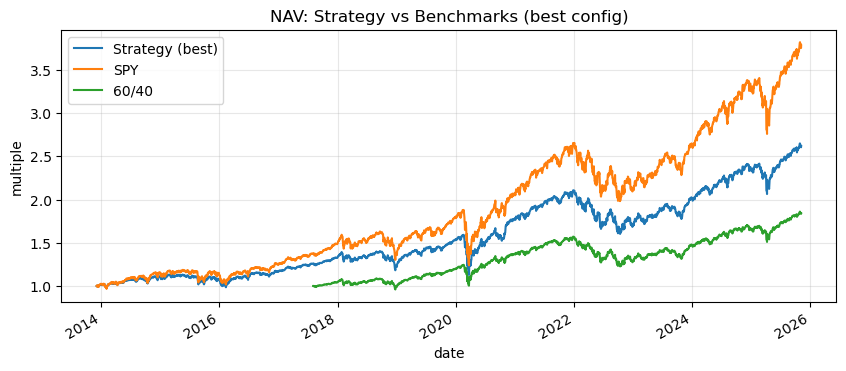

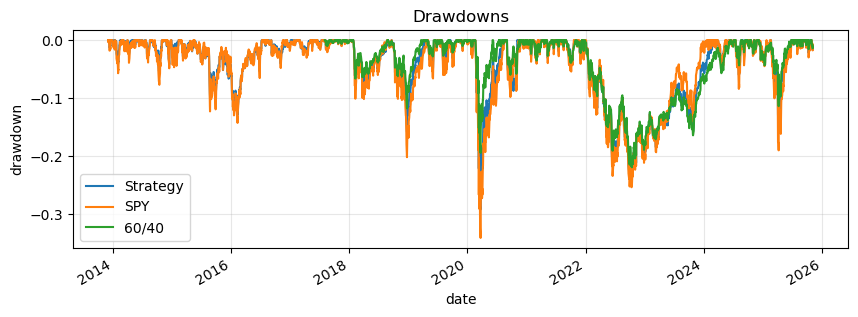

In [22]:
# Grid search (threshold × weights × lag × slippage) + scenario PnL + charts 

# Preconditions
assert "rets" in globals() and not rets.empty
assert "stress" in globals() and isinstance(stress, pd.Series) and not stress.empty
assert "SCENARIOS" in globals()

# --- Helpers ---
def portfolio_returns(R: pd.DataFrame, w: Dict[str, float]) -> pd.Series:
    W = pd.Series(w, dtype=float)
    cols = [c for c in W.index if c in R.columns]
    return R[cols].mul(W.loc[cols], axis=1).sum(axis=1)

def kpis(r: pd.Series, freq: int = 252) -> dict:
    r = pd.Series(r).dropna()
    n = int(len(r))
    if n == 0:
        return {"ann_return": None, "ann_vol": None, "sharpe": None, "max_drawdown": None}
    ann_ret = (1.0 + r).prod() ** (freq / n) - 1.0
    ann_vol = r.std(ddof=0) * np.sqrt(freq)
    sharpe  = (ann_vol and (ann_ret / ann_vol)) or None
    nav = (1.0 + r).cumprod()
    mdd = float((nav / nav.cummax() - 1.0).min()) if len(nav) else None
    return {"ann_return": float(ann_ret), "ann_vol": float(ann_vol), "sharpe": float(sharpe) if sharpe is not None else None, "max_drawdown": mdd}

def drawdown(nav: pd.Series) -> pd.Series:
    nav = nav.dropna()
    return nav / nav.cummax() - 1.0

def total_ret_and_mdd(nav: pd.Series) -> tuple[float, float]:
    nav = nav.dropna()
    if len(nav) < 2:
        return (None, None)
    ret = float(nav.iloc[-1] / nav.iloc[0] - 1.0)
    mdd = float((nav / nav.cummax() - 1.0).min())
    return ret, mdd

# Benchmarks (fixed)
spy_r   = rets["SPY"].dropna()
b6040_r = (0.6 * rets["SPY"] + 0.4 * rets["IEF"]).dropna()

# --- Small grids ---
THRESHOLDS   = [0.15, 0.25, 0.35]
PUB_LAGS_M   = [1, 2]                 # publication lag in months (signal shifted by lag)
SLIP_BPS     = [5, 15, 25]            # penalty on regime switch days
RISK_ON_SET  = [
    {"SPY": 0.7, "HYG": 0.15, "LQD": 0.15},
    {"SPY": 0.6, "HYG": 0.20, "LQD": 0.20},
    {"SPY": 0.5, "HYG": 0.25, "LQD": 0.25},
]
RISK_OFF_SET = [
    {"SH": 0.6, "SJB": 0.2, "IEF": 0.2},
    {"SH": 0.5, "SJB": 0.25, "IEF": 0.25},
    {"SH": 0.7, "SJB": 0.15, "IEF": 0.15},
]

# --- Fallback if SJB history is missing (pre-inception) ---
if "SJB" not in rets.columns:
    for cfg in RISK_OFF_SET:
        if "SJB" in cfg:
            cfg["IEF"] = cfg.get("IEF", 0.0) + cfg.pop("SJB")

rows = []
best = {"sharpe": -1e9, "conf": None, "series": None}

daily_month = rets.index.to_period("M")

for lag_m in PUB_LAGS_M:
    sig = stress.shift(lag_m).dropna()
    sig.index = sig.index.to_period("M")

    for slip in SLIP_BPS:
        slip_dec = slip / 10000.0  # bps → decimal

        for ron in RISK_ON_SET:
            po = portfolio_returns(rets, ron)

            for roff in RISK_OFF_SET:
                pf = portfolio_returns(rets, roff)

                for thr in THRESHOLDS:
                    sleeve_m = (sig > thr).map({True: "risk_off", False: "risk_on"})
                    regime_daily = pd.Series(daily_month.map(sleeve_m), index=rets.index, dtype="object").fillna("risk_on")

                    # switching cost only on regime change days
                    switch = regime_daily.ne(regime_daily.shift(1)).astype(float)
                    cost   = - slip_dec * switch

                    strat_r = pd.Series(
                        np.where(regime_daily.eq("risk_off"), pf.values, po.values),
                        index=rets.index, name="ret"
                    ) + cost

                    stats = kpis(strat_r)

                    grid_id = (
                        f"grid_v1|lag{lag_m}m|slip{slip}bps|thr{thr:.2f}|"
                        f"on_{ron['SPY']:.2f}-{ron['HYG']:.2f}-{ron['LQD']:.2f}|"
                        f"off_{roff['SH']:.2f}-{roff.get('SJB',0.0):.2f}-{roff['IEF']:.2f}"
                    )

                    rows.append({
                        "grid_id": grid_id,
                        "threshold": float(thr),
                        "ann_return": stats["ann_return"],
                        "ann_vol": stats["ann_vol"],
                        "sharpe": stats["sharpe"],
                        "max_drawdown": stats["max_drawdown"],
                        "created_at": pd.Timestamp.utcnow().strftime("%Y-%m-%dT%H:%M:%SZ"),
                    })

                    if stats["sharpe"] is not None and stats["sharpe"] > best["sharpe"]:
                        best = {
                            "sharpe": stats["sharpe"],
                            "conf": {"lag_m": lag_m, "slip_bps": slip, "thr": thr, "risk_on": ron, "risk_off": roff},
                            "series": strat_r.copy(),
                        }

# Log grid → tuning_results (requires UNIQUE on grid_id)
tuning_df = pd.DataFrame(rows).replace({np.nan: None})
upsert_df("tuning_results", tuning_df, on_conflict="grid_id")
print(f"tuning_results upserted: {len(tuning_df)} rows")
print("Best config:", json.dumps(best["conf"], indent=2))
print("Best Sharpe:", round(best["sharpe"], 3))

# Scenario PnL for best config (with empty-window handling) 
best_r   = best["series"]
best_nav = (1 + best_r).cumprod()
spy_nav  = (1 + spy_r).cumprod().reindex(best_nav.index).ffill()
b6040_nav= (1 + b6040_r).cumprod().reindex(best_nav.index).ffill()

scenario_rows = []
for s in SCENARIOS:
    a, b = pd.Timestamp(s["start"]), pd.Timestamp(s["end"])
    idx  = best_nav.loc[a:b].index

    if len(idx) == 0:
        scenario_rows.append({
            "scenario_code": s["code"], "name": s["name"],
            "start_date": a.strftime("%Y-%m-%d"), "end_date": b.strftime("%Y-%m-%d"),
            "strategy_return": None, "strategy_mdd": None,
            "spy_return": None, "spy_mdd": None,
            "b6040_return": None, "b6040_mdd": None,
            "created_at": pd.Timestamp.utcnow().strftime("%Y-%m-%dT%H:%M:%SZ"),
        })
        continue

    snav = best_nav.reindex(idx)
    spyn = spy_nav.reindex(idx)
    bnav = b6040_nav.reindex(idx)

    sr, sm = total_ret_and_mdd(snav)
    pr, pm = total_ret_and_mdd(spyn)
    br, bm = total_ret_and_mdd(bnav)

    scenario_rows.append({
        "scenario_code": s["code"], "name": s["name"],
        "start_date": a.strftime("%Y-%m-%d"), "end_date": b.strftime("%Y-%m-%d"),
        "strategy_return": sr, "strategy_mdd": sm,
        "spy_return": pr, "spy_mdd": pm,
        "b6040_return": br, "b6040_mdd": bm,
        "created_at": pd.Timestamp.utcnow().strftime("%Y-%m-%dT%H:%M:%SZ"),
    })

scenario_df = pd.DataFrame(scenario_rows).replace({np.nan: None})
upsert_df("scenario_pnl", scenario_df, on_conflict="scenario_code")
print("scenario_pnl upserted:", len(scenario_df), "rows")
display(scenario_df)

#Charts: NAV & Drawdown
fig, ax = plt.subplots(figsize=(10, 4))
best_nav.plot(ax=ax, label="Strategy (best)")
spy_nav.plot(ax=ax, label="SPY")
b6040_nav.plot(ax=ax, label="60/40")
ax.set_title("NAV: Strategy vs Benchmarks (best config)")
ax.set_xlabel("date"); ax.set_ylabel("multiple")
ax.grid(True, alpha=0.3); ax.legend(loc="best")
plt.show()

fig, ax = plt.subplots(figsize=(10, 3.2))
drawdown(best_nav).plot(ax=ax, label="Strategy")
drawdown(spy_nav).plot(ax=ax, label="SPY")
drawdown(b6040_nav).plot(ax=ax, label="60/40")
ax.set_title("Drawdowns")
ax.set_xlabel("date"); ax.set_ylabel("drawdown")
ax.grid(True, alpha=0.3); ax.legend(loc="best")
plt.show()


* The grid picked a more conservative regime: 2-month publication lag, higher stress threshold (0.35), and a **heavier risk-off** sleeve (SH/SJB/IEF = 70/15/15). Net of 5 bps switch costs it delivers the **best Sharpe ≈ 0.62**, improving on your prior ~0.60.

* From the chart, the strategy compounding sits **between SPY and 60/40** with **shallower drawdowns than SPY** (notably in COVID and 2022), though it doesn’t beat SPY’s late-cycle melt-up.

* Scenario cuts: COVID drawdown improves vs SPY (-29% vs -34%); **Hikes-2022** is similar to SPY and worse than 60/40; **Oil-2014** is slightly negative while SPY ≈ flat. The `None` cells (e.g., 60/40 in Oil-2014) reflect **data gaps** in the benchmark slice—fill/extend IEF history or compute 60/40 off total-return proxies to complete those rows.
